=== MEMULAI ANALISIS TREN WAKTU (INTERVAL SEMESTER) ===
✅ GRAFIK SEMESTER JADI! Berhasil disimpan sebagai 'trend_sentimen_semester_master.png'


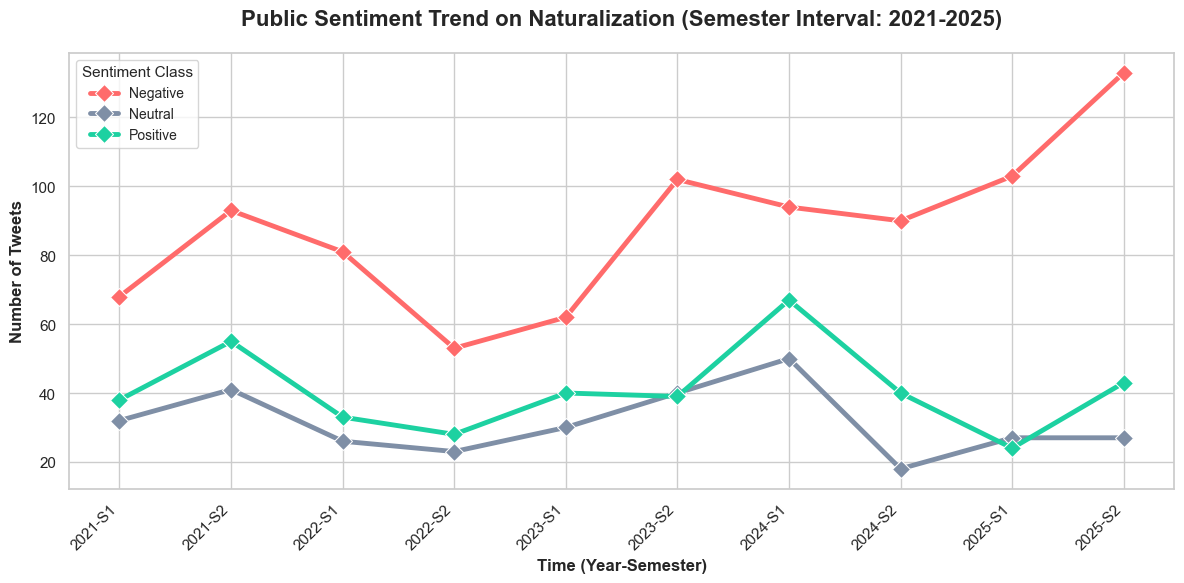

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=== MEMULAI ANALISIS TREN WAKTU (INTERVAL SEMESTER) ===")

# 1. Load Data Master
df = pd.read_csv("master_dataset_fixed.csv")

# ==========================================
# 2. CLEANING & FILTERING (JALAN AMAN 1600 DATA)
# ==========================================
# Buang baris yang format waktunya hancur
df['createdAt'] = pd.to_datetime(df['createdAt'], errors='coerce')
df = df.dropna(subset=['createdAt']) 

# Buang data pseudo_pool (400 data) yang labelnya masih kosong/NaN
df = df.dropna(subset=['label'])

# Pastikan label jadi integer biar gak error pas di-map
df['label'] = df['label'].astype(int) 

# 3. MAGIC TRICK: Bikin Interval Semester (S1 & S2)
df['Tahun'] = df['createdAt'].dt.year.astype(str)
# np.where: Kalau bulan <= 6 (Jan-Jun) = S1, sisanya (Jul-Des) = S2
df['Semester'] = np.where(df['createdAt'].dt.month <= 6, 'S1', 'S2')
df['YearSemester'] = df['Tahun'] + '-' + df['Semester'] 

# 4. Mapping Sentimen
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
df['Sentiment'] = df['label'].map(label_map)

# 5. Hitung frekuensi per Semester
trend_df = df.groupby(['YearSemester', 'Sentiment']).size().reset_index(name='Jumlah')

# 6. PLOTTING GRAFIK GARIS (SEMESTER)
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Bikin garisnya
ax = sns.lineplot(
    data=trend_df, 
    x='YearSemester', 
    y='Jumlah', 
    hue='Sentiment',
    palette={'Negative': '#ff6b6b', 'Neutral': '#7f8fa6', 'Positive': '#1dd1a1'},
    marker='D', # Pake marker Diamond (wajik)
    linewidth=3.5, 
    markersize=9
)

# Percantik tampilannya
plt.title('Public Sentiment Trend on Naturalization (Semester Interval: 2021-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Time (Year-Semester)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Tweets', fontsize=12, fontweight='bold')

# Miringin teks sumbu X dikit biar rapi dan gampang dibaca
plt.xticks(rotation=45, ha='right', fontsize=11) 
plt.legend(title='Sentiment Class', title_fontsize='11', fontsize='10', loc='upper left')

plt.tight_layout()

# Save ke resolusi tinggi
plt.savefig('trend_sentimen_semester_master.png', dpi=300)
print("✅ GRAFIK SEMESTER JADI! Berhasil disimpan sebagai 'trend_sentimen_semester_master.png'")

plt.show()